# Logistic Regression

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    run_stratified_cv,
    run_seed_sweep, SweepResult,
    print_sweep_classification_report,
    print_sweep_performance_summary,
    print_sweep_error_patterns,
    plot_sweep_f1_bar, plot_sweep_confusion_matrix,
    plot_sweep_linear_coefficients, plot_sweep_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

for col in FEATURES:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=lo, upper=hi)

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features (train): 343 → 0 nulls
[Tier 5a] st_met: filled 343 via grouped median by spectral type (train)
[Tier 5b] st_age: filled 988 via RF regression + median fallback (train)
[Tier 6] KNN imputer (train): 97 → 0 nulls

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 17)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 17) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
}

grid_lr = run_grid_search(
    LogisticRegression(
        solver="saga", class_weight=class_weight_dict,
        max_iter=2000, random_state=42,
    ),
    param_grid,
    X_train_bal,
    y_train_bal,
)
lr = grid_lr.best_estimator_

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)

print("Logistic Regression training complete.")
print(f"Best C:           {grid_lr.best_params_['C']}")
print(f"Best penalty:     {grid_lr.best_params_['penalty']}")
print(f"Best CV F1 Macro: {grid_lr.best_score_:.4f}")

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-p

Logistic Regression training complete.
Best C:           100
Best penalty:     l2
Best CV F1 Macro: 0.9429


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Seed-Sweep Evaluation

Grid search above tuned `C` and `penalty` on `random_state=42` only. The single test F1 macro from one split is a noisy estimate when minority test classes have only 6 mesoplanet and 8 psychroplanet samples. Re-evaluate with the tuned hyperparameters across 50 random splits, capturing per-seed confusion matrices, OvR coefficients, and predicted probabilities for downstream aggregated diagnostics.

Like Linear SVM, LogReg's OvR coefficient signs are semantically stable across seeds (positive weight = pushes toward this class regardless of which training samples were drawn), so signed averaging of `coef_` is meaningful — unlike LDA's discriminant axes which suffer sign ambiguity. The regularisation path plot stays at seed=42 because making it sweep-aware would require nested CV (50 grid searches).

In [4]:
sweep_lr = run_seed_sweep(
    lambda cw: LogisticRegression(
        **grid_lr.best_params_,
        solver="saga",
        class_weight=cw,
        max_iter=2000,
        random_state=42,
    ),
    df,
    n_seeds=50,
    model_name="LR",
    save_csv="sweep_logreg.csv",
    save_pickle="sweep_logreg.pkl",
)

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.

LR — 50-seed sweep
  F1 macro:    0.5176 ± 0.0362  (SEM 0.0051, min 0.4392, max 0.6063)
  F1 weighted: 0.9639 ± 0.0047
  Captured per-seed: predict_proba, decision_function, coef_
  F1 DataFrame saved to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_logreg.csv
  Full SweepResult pickled to /Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/basic_models/../data/output/seed_sweep_results/sweep_logreg.pkl


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Modeling
### DIAGNOSTIC PLOT 1: Feature Coefficients (OvR)

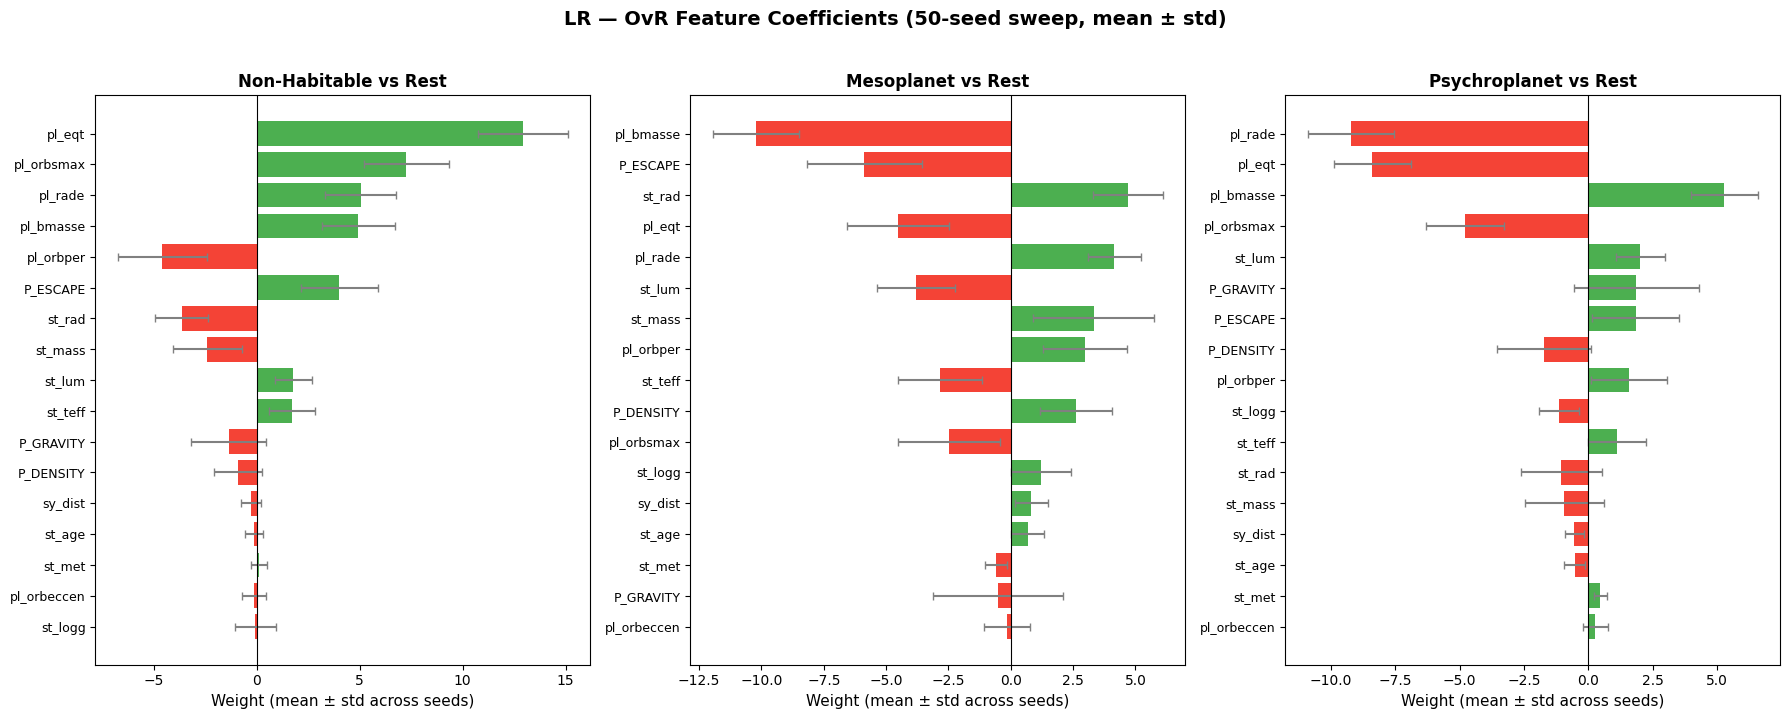

↑ Each panel = the OvR binary classifier 'this class vs the other two'.
  Bar position = mean coefficient across 50 fits. Error bar = std.
  Green = positive (this feature pushes the sample TOWARD this class),
  Red = negative (pushes AWAY). Signs are stable across seeds — no flip ambiguity.
  L1 penalty (best=l2) produces sparse coefficients —
  features with mean near zero AND small std were consistently zeroed out by L1.
  Wide error bars = unstable feature role across training samples.


In [5]:
plot_sweep_linear_coefficients(sweep_lr)

print("↑ Each panel = the OvR binary classifier 'this class vs the other two'.")
print("  Bar position = mean coefficient across 50 fits. Error bar = std.")
print("  Green = positive (this feature pushes the sample TOWARD this class),")
print("  Red = negative (pushes AWAY). Signs are stable across seeds — no flip ambiguity.")
print(f"  L1 penalty (best={grid_lr.best_params_['penalty']}) produces sparse coefficients —")
print("  features with mean near zero AND small std were consistently zeroed out by L1.")
print("  Wide error bars = unstable feature role across training samples.")

### DIAGNOSTIC PLOT 2: Regularisation Path (C vs CV F1 Macro)

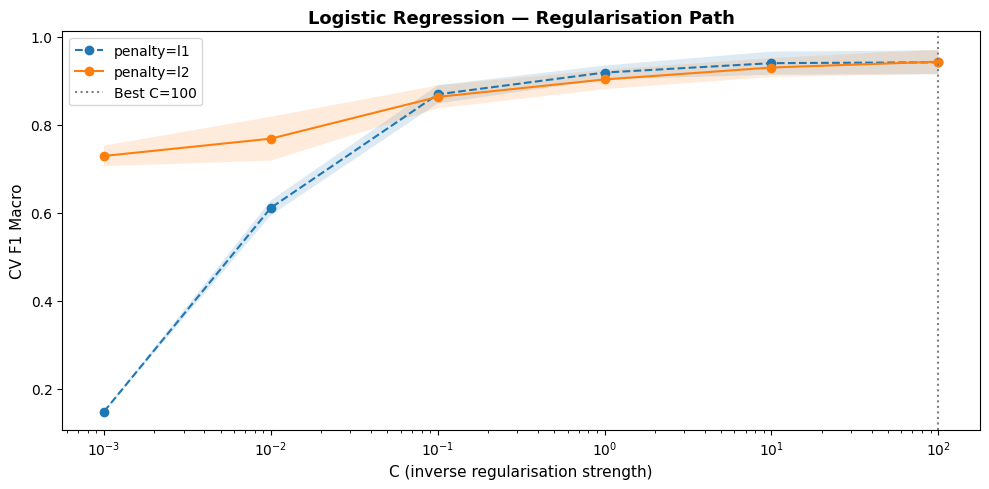

↑ Low C = strong regularisation (high bias). High C = weak regularisation (high variance).
  Shaded band = ±1 std across CV folds.
  L1 often plateaus earlier — sparsity acts as implicit feature selection.


In [6]:
results_df = pd.DataFrame(grid_lr.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for penalty, ls in [("l1", "--"), ("l2", "-")]:
    sub = results_df[results_df["param_penalty"] == penalty].sort_values("param_C")
    ax.plot(sub["param_C"], sub["mean_test_score"],
            marker="o", ls=ls, label=f"penalty={penalty}")
    ax.fill_between(
        sub["param_C"],
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.axvline(grid_lr.best_params_["C"], color="gray", ls=":", lw=1.5,
           label=f"Best C={grid_lr.best_params_['C']}")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularisation strength)", fontsize=11)
ax.set_ylabel("CV F1 Macro", fontsize=11)
ax.set_title("Logistic Regression — Regularisation Path", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("lr_regularisation_path")
plt.show()

print("↑ Low C = strong regularisation (high bias). High C = weak regularisation (high variance).")
print("  Shaded band = ±1 std across CV folds.")
print("  L1 often plateaus earlier — sparsity acts as implicit feature selection.")

### DIAGNOSTIC PLOT 3: Posterior Probability Distributions

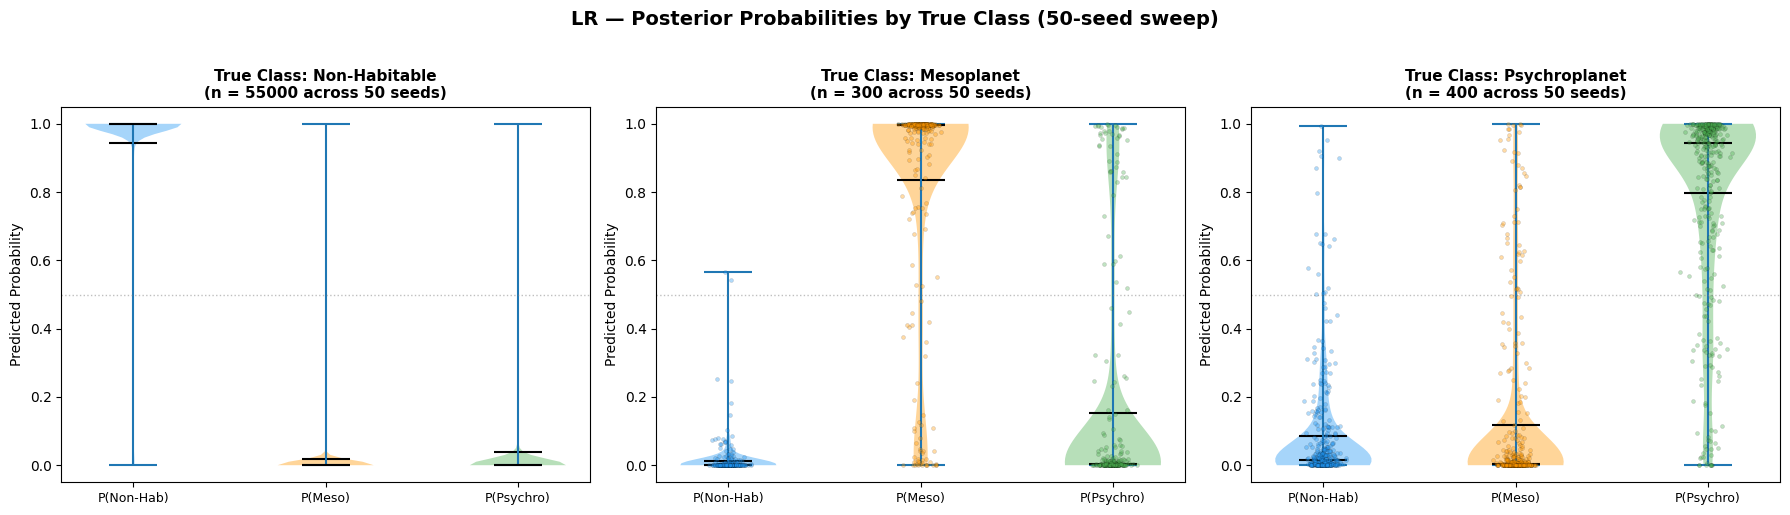

↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,
  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 probability
  points per minority panel, the violins now carry real statistical mass.
  A well-calibrated LogReg concentrates P(true class) near 1.0 across most splits.
  Wide spread = the model is uncertain across different training samples.


In [7]:
plot_sweep_posterior_violins(sweep_lr)

print("↑ Each panel = predicted class probabilities for samples whose TRUE class is labelled above,")
print("  aggregated across all 50 sweep seeds. With 50 splits × 6 mesoplanet = 300 probability")
print("  points per minority panel, the violins now carry real statistical mass.")
print("  A well-calibrated LogReg concentrates P(true class) near 1.0 across most splits.")
print("  Wide spread = the model is uncertain across different training samples.")

## Metrics
### Classification Report

LR — Classification Report (50-seed sweep)
Class               F1 mean     F1 std     F1 min     F1 max
----------------------------------------------------------------
Non-Habitable        0.9726     0.0043     0.9623     0.9806
Mesoplanet           0.3260     0.0955     0.1600     0.6316
Psychroplanet        0.2541     0.0536     0.1455     0.4000
----------------------------------------------------------------
Macro avg            0.5176     0.0362     0.4392     0.6063
Weighted avg         0.9639     0.0047     0.9536     0.9725


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or '


5-Fold CV F1 Macro: 0.9357 ± 0.0105

LR — Performance Summary (50-seed sweep)

Per-class Precision and Recall (mean ± std)
                 Precision            Recall              
Non-Habitable    0.9996 ± 0.0007    0.9470 ± 0.0082
Mesoplanet       0.2052 ± 0.0713    0.8433 ± 0.1558
Psychroplanet    0.1508 ± 0.0353    0.8325 ± 0.1374
----------------------------------------------------------------
Macro avg        0.4518 ± 0.0254    0.8743 ± 0.0674
Weighted avg     0.9892 ± 0.0009    0.9456 ± 0.0082

Aggregate Robustness Metrics
----------------------------------------------------------------
  Accuracy               0.9456 ± 0.0082    
  Balanced accuracy      0.8743 ± 0.0674    (= macro recall)
  Matthews Corr. Coef.   0.3907 ± 0.0387    (−1 to +1; 0 = chance)
  Minority F1 macro      0.2900 ± 0.0528    (meso + psychro only)


/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


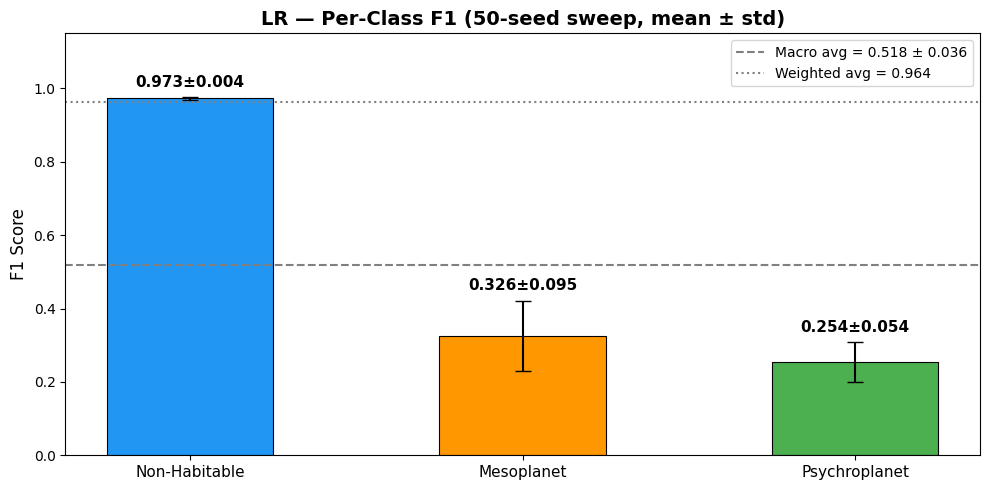

In [8]:
# Per-class F1 with mean ± std from the seed sweep
print_sweep_classification_report(sweep_lr)

# 5-fold CV on the balanced training set — orthogonal to sweep variance,
# measures within-seed tuning stability (different question).
cv_scores_lr = run_stratified_cv(lr, X_train_bal, y_train_bal)

# Cross-model comparison metrics: per-class P/R + aggregate robustness scores
# (MCC, balanced accuracy, minority F1 macro)
print_sweep_performance_summary(sweep_lr)

# Per-class bar chart with error bars from the sweep distribution
plot_sweep_f1_bar(sweep_lr)

### Confusion Matrices (Counts + Normalized)

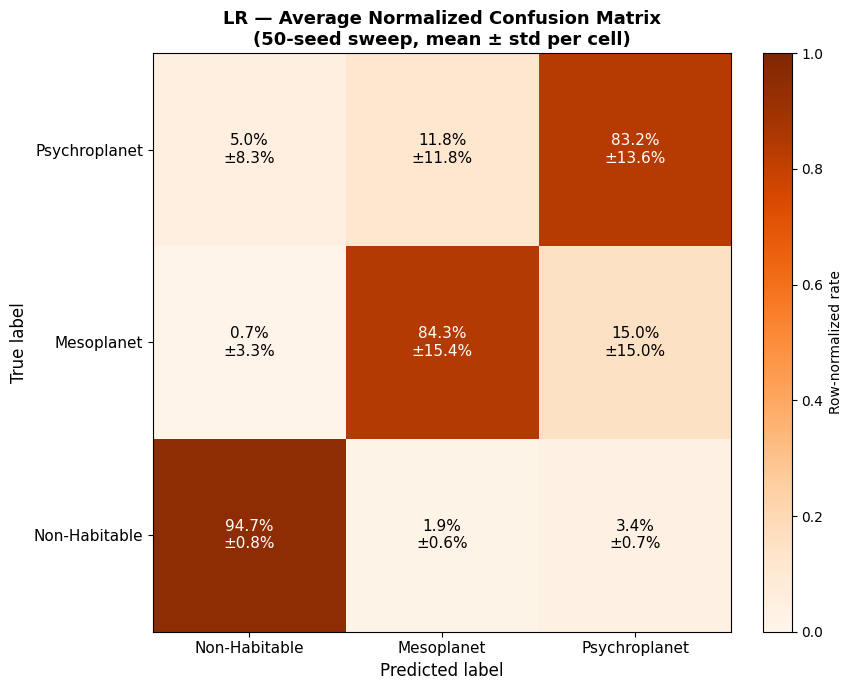

Key error patterns (50-seed sweep):
  Non-Habitable → predicted Mesoplanet: 20.44 ± 6.77 per split  (1.9% ± 0.6% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 37.88 ± 7.93 per split  (3.4% ± 0.7% of true Non-Habitable)
  Mesoplanet → predicted Non-Habitable: 0.04 ± 0.20 per split  (0.7% ± 3.3% of true Mesoplanet)
  Mesoplanet → predicted Psychroplanet: 0.90 ± 0.90 per split  (15.0% ± 15.0% of true Mesoplanet)
  Psychroplanet → predicted Non-Habitable: 0.40 ± 0.66 per split  (5.0% ± 8.3% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 0.94 ± 0.95 per split  (11.8% ± 11.8% of true Psychroplanet)


In [9]:
# Average row-normalized CM across all 50 seeds, annotated per-cell with std
plot_sweep_confusion_matrix(sweep_lr)

# Off-diagonal patterns: per-split count and per-class rate, both mean ± std
print_sweep_error_patterns(sweep_lr)

## Interpretation: